# Sentiment Analysis using NLTK

## Setup

In [1]:
pip install nltk

Note: you may need to restart the kernel to use updated packages.


In [2]:
## Import NLTK
import nltk

In [3]:
## Downloading data from NLTK
nltk.download("movie_reviews") # Dataset: 2000 labeled IMDB reviews
nltk.download("stopwords") # Common English words to remove
nltk.download("wordnet") # Vocabulary for lemmatization
nltk.download("vader_lexicon")  # VADER Sentiment Dictionary
nltk.download("punkt") # Tokenizer Rules
nltk.download("punkt_tab")

[nltk_data] Downloading package movie_reviews to
[nltk_data]     /Users/apple/nltk_data...
[nltk_data]   Package movie_reviews is already up-to-date!
[nltk_data] Downloading package stopwords to /Users/apple/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /Users/apple/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Users/apple/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
[nltk_data] Downloading package punkt to /Users/apple/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /Users/apple/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

## VADER: Instant Sentiment Scoring

No tranining required. VADER uses pre-built dictionary of words with sentiment scores.

It returns 4 values for any text: pos, neu, neg, overall score (-1.0 most negative to +1.0 most positive)

In [4]:
# Initialize VADER
from nltk.sentiment import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

# Sample sentences to demonstrate VADER
sample_sentences = [
    "This movie was absolutely fantastic! One of the best films I have ever seen.",
    "Terrible acting, a complete waste of time. I want my money back.",
    "The movie was okay. Nothing special, but not bad either.",
    "This movie is not bad at all.",
    "An unexpectedly brilliant film — I was moved to tears."
]

In [5]:
vader_sample = sia.polarity_scores(sample_sentences[0])
vader_sample

{'neg': 0.0, 'neu': 0.567, 'pos': 0.433, 'compound': 0.855}

As the compound is more than 0.05, the sentence carries a positive sentiment overall.

## Text Preprocessing with NLTK

Before training ML model, we clean the raw text as filler words, punctuations don't carry any sentiment.

**Preprocessing steps**:
1. Convert to lowercase
2. Remove punctuation and numbers
3. Tokenize (split into words)
4. Remove stop words
5. Lemmatize (reduce to root form)

In [6]:
from nltk.corpus import movie_reviews, stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import pandas as pd
import re
import matplotlib.pyplot as plt

In [7]:
dir(stopwords)

['_LazyCorpusLoader__args',
 '_LazyCorpusLoader__kwargs',
 '_LazyCorpusLoader__load',
 '_LazyCorpusLoader__name',
 '_LazyCorpusLoader__reader_cls',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__name__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_unload',
 'subdir']

In [8]:
stop_words = set(stopwords.words('English'))

In [9]:
lemmatizer = WordNetLemmatizer()

In [10]:
def preprocess(text):
    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-z\s]', '', text)

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stop words
    tokens = [token for token in tokens if token not in stop_words]

    # Lemmatize: convert it back to root word
    tokens  = [lemmatizer.lemmatize(token) for token in tokens]

    # Join tokens back to string
    return " ".join(tokens)

In [11]:
raw = "The actors were BRILLIANT, but the plot was boring!!!"

lower = raw.lower()
lower

'the actors were brilliant, but the plot was boring!!!'

In [12]:
text = re.sub(r'[^a-z\s]', '', lower)
text

'the actors were brilliant but the plot was boring'

In [13]:
tokens = word_tokenize(text)
tokens

['the', 'actors', 'were', 'brilliant', 'but', 'the', 'plot', 'was', 'boring']

In [14]:
tokens = [t for t in tokens if t not in stop_words]
tokens

['actors', 'brilliant', 'plot', 'boring']

In [15]:
lemmatize_tokens = [lemmatizer.lemmatize(t) for t in tokens]
lemmatize_tokens

['actor', 'brilliant', 'plot', 'boring']

## Explore Movie Reviews Dataset

In [16]:
dir(movie_reviews)

['_LazyCorpusLoader__args',
 '_LazyCorpusLoader__kwargs',
 '_LazyCorpusLoader__load',
 '_LazyCorpusLoader__name',
 '_LazyCorpusLoader__reader_cls',
 '__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__firstlineno__',
 '__format__',
 '__ge__',
 '__getattr__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__name__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__static_attributes__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_unload',
 'subdir']

In [17]:
movie_reviews.categories()

['neg', 'pos']

In [18]:
len(movie_reviews.fileids('pos'))

1000

In [19]:
len(movie_reviews.fileids('neg'))

1000

In [20]:
len(movie_reviews.fileids())

2000

A total of 2000 reviews with 1000 positive and 1000 negative.

In [21]:
[m for m in dir(movie_reviews) if not m.startswith('_')]

['CorpusView',
 'abspath',
 'abspaths',
 'categories',
 'citation',
 'encoding',
 'ensure_loaded',
 'fileids',
 'license',
 'open',
 'paras',
 'raw',
 'readme',
 'root',
 'sents',
 'subdir',
 'words']

In [22]:
# A sample positive review
print(movie_reviews.raw(movie_reviews.fileids('pos')[0])[:500])

films adapted from comic books have had plenty of success , whether they're about superheroes ( batman , superman , spawn ) , or geared toward kids ( casper ) or the arthouse crowd ( ghost world ) , but there's never really been a comic book like from hell before . 
for starters , it was created by alan moore ( and eddie campbell ) , who brought the medium to a whole new level in the mid '80s with a 12-part series called the watchmen . 
to say moore and campbell thoroughly researched the subject


In [23]:
# A sample negative review
print(movie_reviews.raw(movie_reviews.fileids('neg')[0])[:500])

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt


In [24]:
movie_reviews.fileids()

['neg/cv000_29416.txt',
 'neg/cv001_19502.txt',
 'neg/cv002_17424.txt',
 'neg/cv003_12683.txt',
 'neg/cv004_12641.txt',
 'neg/cv005_29357.txt',
 'neg/cv006_17022.txt',
 'neg/cv007_4992.txt',
 'neg/cv008_29326.txt',
 'neg/cv009_29417.txt',
 'neg/cv010_29063.txt',
 'neg/cv011_13044.txt',
 'neg/cv012_29411.txt',
 'neg/cv013_10494.txt',
 'neg/cv014_15600.txt',
 'neg/cv015_29356.txt',
 'neg/cv016_4348.txt',
 'neg/cv017_23487.txt',
 'neg/cv018_21672.txt',
 'neg/cv019_16117.txt',
 'neg/cv020_9234.txt',
 'neg/cv021_17313.txt',
 'neg/cv022_14227.txt',
 'neg/cv023_13847.txt',
 'neg/cv024_7033.txt',
 'neg/cv025_29825.txt',
 'neg/cv026_29229.txt',
 'neg/cv027_26270.txt',
 'neg/cv028_26964.txt',
 'neg/cv029_19943.txt',
 'neg/cv030_22893.txt',
 'neg/cv031_19540.txt',
 'neg/cv032_23718.txt',
 'neg/cv033_25680.txt',
 'neg/cv034_29446.txt',
 'neg/cv035_3343.txt',
 'neg/cv036_18385.txt',
 'neg/cv037_19798.txt',
 'neg/cv038_9781.txt',
 'neg/cv039_5963.txt',
 'neg/cv040_8829.txt',
 'neg/cv041_22364.txt',


In [25]:
movie_reviews.raw(movie_reviews.fileids()[0])

'plot : two teen couples go to a church party , drink and then drive . \nthey get into an accident . \none of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . \nwhat\'s the deal ? \nwatch the movie and " sorta " find out . . . \ncritique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . \nwhich is what makes this review an even harder one to write , since i generally applaud films which attempt to break the mold , mess with your head and such ( lost highway & memento ) , but there are good and bad ways of making all types of films , and these folks just didn\'t snag this one correctly . \nthey seem to have taken this pretty neat concept , but executed it terribly . \nso what are the problems with the movie ? \nwell , its main problem is that it\'s simply too jumbled . \nit starts off " normal " but then downshifts into this " fantasy " world in which you , as an audience membe

In [26]:
# Build the full dataset as list of texts and labels

text = []
label = []

for category in movie_reviews.categories():
    for file_id in movie_reviews.fileids(category):
        raw_text = movie_reviews.raw(file_id)
        text.append(raw_text)
        label.append(category)

In [27]:
cleaned_text = [preprocess(t) for t in text]
cleaned_text[0][:500]
type(cleaned_text)

list

In [28]:
print(text[0][:500])

plot : two teen couples go to a church party , drink and then drive . 
they get into an accident . 
one of the guys dies , but his girlfriend continues to see him in her life , and has nightmares . 
what's the deal ? 
watch the movie and " sorta " find out . . . 
critique : a mind-fuck movie for the teen generation that touches on a very cool idea , but presents it in a very bad package . 
which is what makes this review an even harder one to write , since i generally applaud films which attempt


## Feature Extraction with TF-IDF

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(cleaned_text,
                                                    label,
                                                    test_size=0.2,
                                                    random_state=42,
                                                    stratify=label)

In [30]:
len(X_train)

1600

In [31]:
len(X_test)

400

In [32]:
len(y_train)

1600

In [33]:
len(y_test)

400

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000) # 10,000 most important words

In [35]:
X_train_tfidf = vectorizer.fit_transform(X_train)

In [36]:
X_test_tfidf = vectorizer.transform(X_test)

In [37]:
# Some of the vocabulary learned by the vectorizer
len(vectorizer.get_feature_names_out())

10000

## Train and Compare Classifiers

In [38]:
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

In [39]:
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report

In [40]:
nb_model = MultinomialNB()
nb_model.fit(X_train_tfidf, y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [41]:
y_pred_nb = nb_model.predict(X_test_tfidf)
accuracy_nb = accuracy_score(y_test, y_pred_nb)

In [42]:
accuracy_nb

0.8075

In [43]:
lr_model = LogisticRegression()
lr_model.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [44]:
y_pred_lr = lr_model.predict(X_test_tfidf)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

In [45]:
accuracy_lr

0.83

In [46]:
print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         neg       0.85      0.80      0.82       200
         pos       0.81      0.86      0.83       200

    accuracy                           0.83       400
   macro avg       0.83      0.83      0.83       400
weighted avg       0.83      0.83      0.83       400



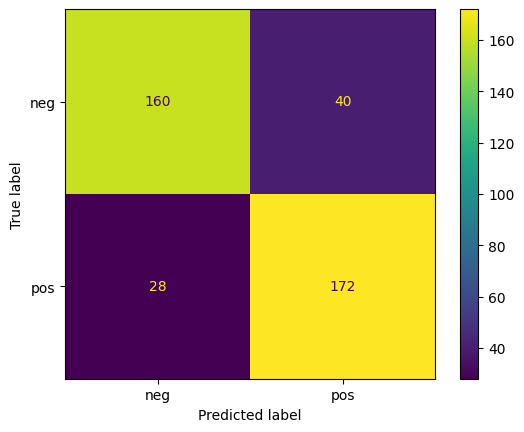

In [47]:
ConfusionMatrixDisplay.from_estimator(lr_model, X_test_tfidf, y_test)

In [48]:
lr_model.coef_[0]

array([ 0.20382738,  0.01480877, -0.06165236, ...,  0.17081556,
       -0.1813312 ,  0.05762766], shape=(10000,))

In [49]:
review = "The Dark Knight is an absolute masterpiece. Christopher Nolan delivers a gripping, intense story that keeps you on the edge of your seat from start to finish. Heath Ledger's performance as the Joker is nothing short of legendary — chaotic, terrifying, and deeply compelling. The action sequences are brilliant, the screenplay is tight, and the cinematography is stunning. However, the film is quite long and some middle sections feel slightly slow. Overall, one of the greatest superhero films ever made and a landmark in modern cinema."

In [50]:
review_preprocessed = preprocess(review)

In [51]:
tf_idf_test = vectorizer.transform([review_preprocessed])

In [52]:
lr_model.predict(tf_idf_test)

array(['pos'], dtype='<U3')

In [53]:
lr_model.predict_proba(tf_idf_test)

array([[0.2648937, 0.7351063]])

In [54]:
## Top 5 negative words
features = vectorizer.get_feature_names_out()
top_neg_idx = lr_model.coef_[0].argsort()[:15]

In [55]:
pd.Series(data=lr_model.coef_[0][top_neg_idx], index=features[top_neg_idx])

bad             -2.834186
worst           -1.703832
plot            -1.531780
boring          -1.412059
nothing         -1.343135
supposed        -1.233093
script          -1.232701
attempt         -1.149887
stupid          -1.095320
unfortunately   -1.042565
look            -1.025118
movie           -1.018185
waste           -1.005274
mess            -0.998556
harry           -0.968831
dtype: float64

In [56]:
lr_model.coef_[0].argsort()[::-1][:15]

array([3882, 9686, 6535,  247, 5167, 3044, 3191,  815, 6531, 9257, 5470,
       9899,  221, 4704, 6352])

In [57]:
# Top 15 positive words
top_pos_idx = lr_model.coef_[0].argsort()[::-1][:15]
pd.Series(data=lr_model.coef_[0][top_pos_idx], index=features[top_pos_idx])

great          1.569798
war            1.360905
performance    1.285871
also           1.262248
life           1.160602
excellent      1.055614
family         1.043133
best           1.012101
perfect        1.008624
truman         0.996584
many           0.942266
world          0.929821
alien          0.919135
jackie         0.903430
overall        0.902484
dtype: float64

## ANOTHER DATASET

In [64]:
# nltk.download('sentence_polarity')

In [65]:
# from nltk.corpus import sentence_polarity

In [66]:
# dir(sentence_polarity)

In [67]:
# sentence_polarity.categories()

In [68]:
# len(sentence_polarity.fileids('pos'))

In [69]:
# len(sentence_polarity.fileids('neg'))

In [70]:
# print(sentence_polarity.raw(sentence_polarity.fileids('pos')[0])[:500])

In [71]:
# print(sentence_polarity.raw(sentence_polarity.fileids('neg')[0])[:500])

In [72]:
# sentence_polarity.fileids()

In [73]:
## Build the full dataset as list of texts and labels

# text_sp = []
# label_sp = []

# for category_sp in sentence_polarity.categories():
#     for file_id_sp in sentence_polarity.fileids(category_sp):
#         raw_text_sp = sentence_polarity.raw(file_id_sp)
#         text_sp.append(raw_text_sp)
#         label_sp.append(category_sp)

In [74]:
# cleaned_text_sp = [preprocess(t) for t in text_sp]
# cleaned_text_sp[0][:500]

In [75]:
# text_sp[0][:500]

In [76]:
# X_train_sp, X_test_sp, y_train_sp, y_test_sp = train_test_split(cleaned_text_sp,
#                                                     label_sp,
#                                                     test_size=0.2,
#                                                     random_state=42)

In [77]:
# len(X_train_sp)

In [78]:
# len(y_train_sp)

## INSTALLING JOBLIB

In [59]:
!pip3 install joblib

In [60]:
import joblib   #USED TO EXTRACT ONLY THE [MODEL] FROM THE JUPYTER NOTEBOOK

In [61]:
model = joblib.dump(lr_model,'model.joblib')

In [62]:
vectorizer

,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (string transformation) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None
,"analyzer analyzer: {'word', 'char', 'char_wb'} or callable, default='word'Whether the feature should be made of word or character n-grams.Option 'char_wb' creates character n-grams only from text insideword boundaries; n-grams at the edges of words are padded with space.If a callable is passed it is used to extract the sequence of featuresout of the raw, unprocessed input... versionchanged:: 0.21 Since v0.21, if ``input`` is ``'filename'`` or ``'file'``, the data is first read from the file and then passed to the given callable analyzer.",'word'
,"stop_words stop_words: {'english'}, list, default=NoneIf a string, it is passed to _check_stop_list and the appropriate stoplist is returned. 'english' is currently the only supported stringvalue.There are several known issues with 'english' and you shouldconsider an alternative (see :ref:`stop_words`).If a list, that list is assumed to contain stop words, all of whichwill be removed from the resulting tokens.Only applies if ``analyzer == 'word'``.If None, no stop words will be used. In this case, setting `max_df`to a higher value, such as in the range (0.7, 1.0), can automatically detectand filter stop words based on intra corpus document frequency of terms.",None
,"token_pattern token_pattern: str, default=r""(?u)\\b\\w\\w+\\b""Regular expression denoting what constitutes a ""token"", only usedif ``analyzer == 'word'``. The default regexp selects tokens of 2or more alphanumeric characters (punctuation is completely ignoredand always treated as a token separator).If there is a capturing group in token_pattern then thecaptured group content, not the entire match, becomes the token.At most one capturing group is permitted.",'(?u)\\b\\w\\w+\\b'
,"ngram_range ngram_range: tuple (min_n, max_n), default=(1, 1)The lower and upper boundary of the range of n-values for differentn-grams to be extracted. All values of n such that min_n <= n <= max_nwill be used. For example an ``ngram_range`` of ``(1, 1)`` means onlyunigrams, ``(1, 2)`` means unigrams and bigrams, and ``(2, 2)`` meansonly bigrams.Only applies if ``analyzer`` is not callable.","(1

In [63]:
tf_idf = joblib.dump(vectorizer,'tf_idf.joblib')

In [64]:
#LOADING THE MODEL
load_model = joblib.load('model.joblib')

In [65]:
#LOADING THE TF IDF VECTORIZER
tf_idf_load = joblib.load('tf_idf.joblib')

In [66]:
review = "This is a brilliantly flopped movie !!"

In [67]:
preprocess_review = preprocess(review)
preprocess_review

'brilliantly flopped movie'

In [68]:
features = tf_idf_load.transform([preprocess_review])
features

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3 stored elements and shape (1, 10000)>

In [69]:
load_model.predict(features)

array(['pos'], dtype='<U3')